In [1]:
from groq_llm import get_groq_llm
from langchain.messages import HumanMessage, AIMessage
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

import json

e:\QanoonAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class LegalSchema(TypedDict):
    query: str
    tools: List[str] = ["legal_rag", "user_files", "web_search"]
    rag_context : str
    web_search_context : str
    user_files_context : str
    final_answer: str

In [3]:
llm = get_groq_llm()

In [4]:
#llm.invoke([HumanMessage("Hello how are you?")]).content

In [5]:
def router_node(state: dict):
    query = state["query"]

    prompt = f"""
You are a legal AI routing engine.

You MUST return ONLY valid JSON.

Schema:

  "query": "string (optimized query)",
  "tools": ["legal_rag", "user_files", "web_search"]
Rules:
- Output ONLY JSON
- No markdown
- No explanation

User Query:
{query}
"""

    response = llm.invoke(prompt)
    
    return json.loads(response.content)   

In [6]:
# res = router_node({"query": "What is the statute of limitations for a breach of contract in California?"})

In [7]:
# True if 'legal_rag' in res["tools"] else False

In [8]:
from tools.rag_pipeline import rag_context_collector
from tools.web_search import run_web_search


def legal_rag(state: LegalSchema) -> LegalSchema:

    query = state["query"]
    
    context = rag_context_collector(query)
    
    return {"rag_context": context}

def user_files(state: LegalSchema) -> LegalSchema:

    
    return {"user_files_context": "User Files Context"}

def web_search(state: LegalSchema) -> LegalSchema:
    
    query = state["query"]
    results = run_web_search(query)
    
    return {"web_search_context": results}

def context_collector(state: LegalSchema) -> LegalSchema:
    
    llm = get_groq_llm()
    context_dict = {
    "rag_context": state["rag_context"],
    "web_search_context": state["web_search_context"],
    "user_files_context": state["user_files_context"]
}

    prompt = """
    Here the collected context from various tools:
    {context_dict}
    You are a legal AI assistant. Use the above context to answer the user's {{"query": {query}}}
    """.format(context_dict=context_dict, query=state["query"])

    response = llm.invoke(prompt)
    
    return {"final_answer": response.content}

In [9]:
def conditioner(state: LegalSchema) ->LegalSchema:
    tools = state['tools']

    routes = []

    if 'legal_rag' in tools:
        routes.append('legal_rag')
    if 'user_files' in tools:
        routes.append('user_files')
    if 'web_search' in tools:
        routes.append('web_search')
        
    return routes

In [10]:
graph = StateGraph(LegalSchema)

graph.add_node("router_node", router_node)
graph.add_node("user_files", user_files)
graph.add_node("legal_rag", legal_rag)
graph.add_node("web_search", web_search)
graph.add_node("context_collector", context_collector)


graph.add_edge(START, "router_node")
graph.add_conditional_edges("router_node", conditioner, {
    "legal_rag": "legal_rag",
    "user_files": "user_files",
    "web_search": "web_search"
})
graph.add_edge("legal_rag", "context_collector")
graph.add_edge("user_files", "context_collector")
graph.add_edge("web_search", "context_collector")

graph.add_edge("context_collector", END)
gf = graph.compile()

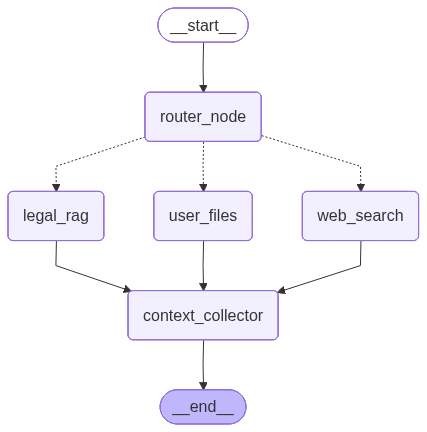

In [11]:
### Show graph structure using ipython
gf


In [12]:
initial_state = {
    "query": "what is punishment for Qatl acc to ppc use only rag?",
    "rag_context": "",
    "web_search_context": "",
    "user_files_context": "",
    "final_answer": ""
}

In [ ]:
ress = gf.invoke(initial_state)

In [ ]:
ress["rag_context"]

"Document: 319. Punishment for qatl-i-khata Whoever commits qatl-i-khata shall be liable to diyat: Provided that, where qatl-i-khata is committed by a rash or negligent act, other than rash or negligent driving, the offender may, in addition to diyat, also be punished with imprisonment of either description for a term which may extend to five years as ta'zir.\nMetadata: {'title': '319. Punishment for qatl-i-khata'}\n\nDocument: 324. Attempt to commit qatl-i-amd - Whoever does any act with such intention or knowledge, and under such circumstances, that, if he by that act caused qatl, he would be guilty of qatl-i-amd, shall be punished with imprisonment for either description for a term which may extend to ten years but shall not be less than five years if the offence has been committed in the name or on the pretext - of honour] and shall also be liable to fine, and, if hurt is caused to any person by such act, the offender shall, in addition to the imprisonment and fine as aforesaid, be

In [ ]:
from IPython.display import Markdown, display
display(Markdown(ress["final_answer"]))

**Punishment for Qatl (“murder”) under the Pakistan Penal Code (as reflected in the excerpts you provided)**  

| Type of Qatl | Legal Provision (Section) | Mandatory / Discretionary Punishment | Maximum / Minimum Imprisonment | Other Consequences |
|--------------|---------------------------|--------------------------------------|--------------------------------|--------------------|
| **Qatl‑i‑khata** (unintentional or “mistake” murder) | 319 | **Diyāt** (blood‑money) is payable. If the act was **rash or negligent** (but not reckless driving), the court may also impose **taʿzīr** (discretionary) imprisonment. | Up to **5 years** (taʿzīr) in addition to diyāt. | Diyāt is paid to the heirs; imprisonment is optional, based on the court’s assessment of negligence. |
| **Qatl‑i‑amd** (premeditated/intentional murder) | 302 | **Qisas** (retributive death) is the primary punishment. If qisas cannot be carried out (e.g., victim’s heirs forgive), the court may impose **taʿzīr**. | • Death (qisas)  <br>• **Life imprisonment** (taʿzīr)  <br>• If qisas is not applicable, imprisonment **up to 25 years**. | The court may also order **diyāt** if the victim’s heirs accept compensation instead of qisas. |
| **Qatl‑shibh‑i‑amd** (murder “similar to” qatl‑i‑amd) | 316 | **Diyāt** is payable; the offender may also receive **taʿzīr** imprisonment. | Up to **25 years** (taʿzīr). | No death penalty is prescribed; the case is treated as a serious homicide with compensation and long‑term imprisonment. |
| **Qatl committed under ikrah‑i‑tam** (full coercion) | 303(a) | Imprisonment for the **type of qatl** committed **plus** a separate penalty for the coercion. | **10 years minimum**, up to **25 years** total. | The person who caused the coercion is punished for the resulting qatl as well. |
| **Qatl committed under ikrah‑i‑naqis** (partial coercion) | 303(b) | Punishment follows the **type of qatl** committed; the coercer receives a separate term. | **Up to 10 years** for the coercer; the principal offender receives the penalty appropriate to the qatl itself. |
| **Attempt to commit qatl‑i‑amd** | 324 | Imprisonment **5 – 10 years** (minimum 5 years) plus a fine. If the attempt causes hurt, the offender is also liable for the punishment for that hurt (including qisas/arsh). | Up to **10 years** (or **7 years** if the hurt is punishable by qisas that is not executable). | Fine is mandatory; additional imprisonment may be added for the hurt caused. |

### Key Points to Remember
1. **Qisas (retributive death)** is the default penalty for intentional murder (qatl‑i‑amd) unless the victim’s heirs waive it or it is otherwise inapplicable.  
2. **Diyāt (blood‑money)** can be paid in place of qisas, or it is the sole remedy for unintentional murder (qatl‑i‑khata) and for qatl‑shibh‑i‑amd.  
3. **Taʿzīr** (discretionary punishment) allows the court to impose imprisonment (and sometimes fines) when qisas is not applied or when the act involves negligence, coercion, or an attempt. The maximum terms range from **5 years** (qatl‑i‑khata) to **25 years** (qatl‑i‑amd when qisas is unavailable, qatl‑shibh‑i‑amd, or ikrah‑i‑tam).  
4. **Coercion (ikrah)** aggravates the sentence: full coercion (ikrah‑i‑tam) raises the minimum imprisonment to **10 years**; partial coercion (ikrah‑i‑naqis) adds up to **10 years** for the coercer.  
5. **Attempted murder** carries a substantial custodial term (minimum 5 years) plus a fine, and any resulting hurt is punished separately.

These provisions together constitute the statutory framework for punishments related to **qatl** (murder) under the Pakistan Penal Code as reflected in the excerpts you provided.

NameError: name 'pretty_print' is not defined